## 변수 간 관계 분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

df = pd.read_csv(r'C:\Users\컴퓨터\Documents\[부캠][basic] 심화프로젝트\2025_Airbnb_NYC_listings.csv') #----- 자기 경로 설정!!
df_cleaned = pd.read_csv(r'C:\Users\컴퓨터\Documents\data-analysis-project-BBB\data\first_clean_data.csv')

In [2]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


# 머신러닝 전용 df 전처리

In [3]:
df_machine = df_cleaned.copy()
df_machine.head()

,Unnamed: 0,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197


In [4]:
df_machine.columns

Index(['Unnamed: 0', 'id', 'name', 'description', 'host_id', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
       'amenities', 'price', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'log_price'],
      dtype='str')

## 컬럼 드랍

In [5]:
drop_cols = ['Unnamed: 0', 'id', 'name', 'description', 'host_id', 'host_since',
        'host_response_time', 'host_response_rate', 'host_acceptance_rate',
        'host_is_superhost', 'neighbourhood_cleansed',
        'latitude', 'longitude',
        'property_type',
        'amenities', 'availability_365', 'number_of_reviews',
        'number_of_reviews_ltm', 'estimated_occupancy_l365d',
        'estimated_revenue_l365d', 'review_scores_rating',
        'review_scores_accuracy', 'review_scores_cleanliness',
        'review_scores_checkin', 'review_scores_communication',
        'review_scores_location', 'review_scores_value',
        'calculated_host_listings_count',
        'calculated_host_listings_count_entire_homes',
        'calculated_host_listings_count_private_rooms',
        'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
        'price']
df_machine=df_machine.drop(columns = drop_cols)

In [6]:
df_machine.info()

<class 'pandas.DataFrame'>
RangeIndex: 22248 entries, 0 to 22247
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   neighbourhood_group_cleansed  22248 non-null  str    
 1   room_type                     22248 non-null  str    
 2   accommodates                  22248 non-null  int64  
 3   bedrooms                      22248 non-null  float64
 4   beds                          22248 non-null  float64
 5   log_price                     22248 non-null  float64
dtypes: float64(3), int64(1), str(2)
memory usage: 1.0 MB


In [7]:
df_machine.shape

(22248, 6)

## 'host_is_superhost', 'neighbourhood_group_cleansed' 'room_type' 값 drop

### 'host_is_superhost' unknown 값 삭제

### 'neighbourhood_group_cleansed' Bronx, Staten Island 값 삭제

In [8]:
neighborhood_idx = df_machine.loc[df_machine['neighbourhood_group_cleansed'].isin(['Bronx','Staten Island'])].index
df_machine = df_machine.drop(neighborhood_idx)

### 'room_type' Hotel room, Shared room

In [9]:
room_idx = df_machine.loc[df_machine['room_type'].isin(['Hotel room','Shared room'])].index
df_machine = df_machine.drop(room_idx)

In [10]:
df_machine.info()

<class 'pandas.DataFrame'>
Index: 20586 entries, 0 to 22247
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   neighbourhood_group_cleansed  20586 non-null  str    
 1   room_type                     20586 non-null  str    
 2   accommodates                  20586 non-null  int64  
 3   bedrooms                      20586 non-null  float64
 4   beds                          20586 non-null  float64
 5   log_price                     20586 non-null  float64
dtypes: float64(3), int64(1), str(2)
memory usage: 1.1 MB


## 'review_scores_accuracy', 'review_scores_rating' null값 drop

In [11]:
# scores_drop = df_machine.loc[(df_machine['review_scores_accuracy'].isna()) & (df_machine['review_scores_rating'].isna())].index
# df_machine = df_machine.drop(scores_drop)

In [12]:
df_machine.shape

(20586, 6)

In [13]:
# df_machine = df_machine.dropna(subset='review_scores_rating')

In [14]:
# df_machine['review_scores_rating'].isna().sum()

In [15]:
# df_machine

------------------------------------

---------------------------------------

# 머신러닝 시작..!

## 1. Train/Test Split: train_test_split 

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df_machine.drop(columns=["log_price"])
y = df_machine["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

----------------------------

## 2. 결측치(Missing): 채우기 + 결측 자체도 피처로

### 2-1. 결측 플래그 만들기

In [17]:
# col = "review_scores_accuracy"
# X_train[f"{col}_isna"] = X_train[col].isna().astype(int)
# X_test[f"{col}_isna"]  = X_test[col].isna().astype(int)

-------------------------------

## 3. 범주형 인코딩(Encoding)

In [18]:
# 2. 원 핫 인코딩
cat_cols = ["neighbourhood_group_cleansed", "room_type"]
X_train_dum = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_dum = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
# 3. reindex(=컬럼 정렬)
X_test_dum = X_test_dum.reindex(columns=X_train_dum.columns, fill_value=0)

두 컬럼 일치

## 4. 스케일링

- (가격만 로그변환)

In [19]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['accommodates','bedrooms','beds']
scale_cols = [c for c in scale_cols if c in X_train_dum.columns]  # 안전장치

scaler = StandardScaler()
X_train_dum[scale_cols] = scaler.fit_transform(X_train_dum[scale_cols])
X_test_dum[scale_cols] = scaler.transform(X_test_dum[scale_cols])

X_train_dum[scale_cols].describe()

,accommodates,bedrooms,beds
count,1.646800e+04,1.646800e+04,1.646800e+04
mean,-5.867975e-17,-7.939025e-17,-1.121819e-17
std,1.000030e+00,1.000030e+00,1.000030e+00
min,-9.565973e-01,-1.424843e+00,-1.427083e+00
25%,-4.498829e-01,-3.381799e-01,-5.515120e-01
50%,-4.498829e-01,-3.381799e-01,-5.515120e-01
75%,5.635459e-01,7.484829e-01,3.240592e-01
max,6.644119e+00,1.487510e+01,1.695991e+01


### 4-1. 여러 가지 가격 파생 컬럼 생성으로 인한 중복되는 의미 컬럼 drop

## 5. 모델 학습 시작! (Random Forest, XGBoost)

### 5-1. Random Forest 모델 불러오고 세팅하기

In [21]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. XGBoost 회귀 모델 생성 및 하이퍼파라미터 세팅
xgb_model = xgb.XGBRegressor(
    n_estimators=100,      # 나무의 개수 (공부할 횟수)
    learning_rate=0.1,     # 학습률: 오답을 한 번에 얼마나 세게 고칠 것인가
    max_depth=5,           # 나무의 최대 깊이 (너무 깊으면 과적합 발생)
    random_state=42,       # 결과 고정
    n_jobs=-1              # 컴퓨터의 모든 코어를 사용해 속도 향상
)

### 5-2. 모델 학습

In [22]:
xgb_model.fit(X_train_dum, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

### 5-3. 예측 및 채점

#### 5-3-1. 채점

In [23]:
# 평가 데이터로 예측 수행
y_pred_xgb = xgb_model.predict(X_test_dum)

In [24]:
# # 5. 채점을 위한 패키지 불러오기
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [25]:
# 실제 정답(y_test)과 모델이 적어낸 답(y_pred)을 비교하여 오차 계산
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"MAE (평균 절대 오차): {mae_xgb:.4f}")
print(f"RMSE (평균 제곱근 오차): {rmse_xgb:.4f}")
print(f"R2 Score (결정계수): {r2_xgb:.4f}")

MAE (평균 절대 오차): 0.4091
RMSE (평균 제곱근 오차): 0.5339
R2 Score (결정계수): 0.5232


In [ ]:
# y_pred_train = rf_model.predict(X_train_dum)

In [ ]:
# r2_train = r2_score(y_train, y_pred_train)

# print(f"R2 Score (결정계수): {r2:.4f}")

#### 5-3-2. 예측

In [ ]:
# # 신규 호스트 가상 데이터 (딕셔너리)
# my_listing = {
#         'price': 1000, 
#         'host_response_time': 1,
#         'host_response_rate': 100,
#         'host_acceptance_rate': 95,
#         'accommodates': 2,
#         'bedrooms': 1,
#         'beds': 2,
#         'availability_365': 200,
#         'number_of_reviews_ltm': 10,
#         'review_scores_accuracy': 5.0,
#         'neighbourhood_group': 'Manhattan', 
#         'room_type': 'Entire home/apt'
#     }

# # 예측 함수 (첫 번째 코드의 전처리 방식을 그대로 따름)
# def predict_with_refined_model(input_data):
#     test_df = pd.DataFrame([input_data])
    
# # 로그 변환
# if 'price' in test_df.columns:
#     test_df['price_log1p'] = np.log1p(test_df['price'])
    
# # 원-핫 인코딩 및 컬럼 맞추기
# # 첫 번째 코드의 X_train_dum 컬럼들을 0으로 초기화한 뒤 매핑
# final_input = pd.DataFrame(0, index=[0], columns=X_train_dum.columns)
    
# for col, value in test_df.iloc[0].items():
#     if col in final_input.columns:
#         final_input[col] = value
#     else:
#         combined_col = f"{col}_{value}"
#         if combined_col in final_input.columns:
#             final_input[combined_col] = 1
    
# # 스케일링 (첫 번째 코드에서 만든 scaler 사용)
# # final_scale_target 리스트를 재사용
# final_input[final_scale_target] = scaler.transform(final_input[final_scale_target])
    
# # 예측
# prediction = model.predict(final_input)[0]
# return prediction

# # 결과 출력
# score = predict_with_refined_model(my_listing)
# print(f"예상 평점: {score:.2f}")

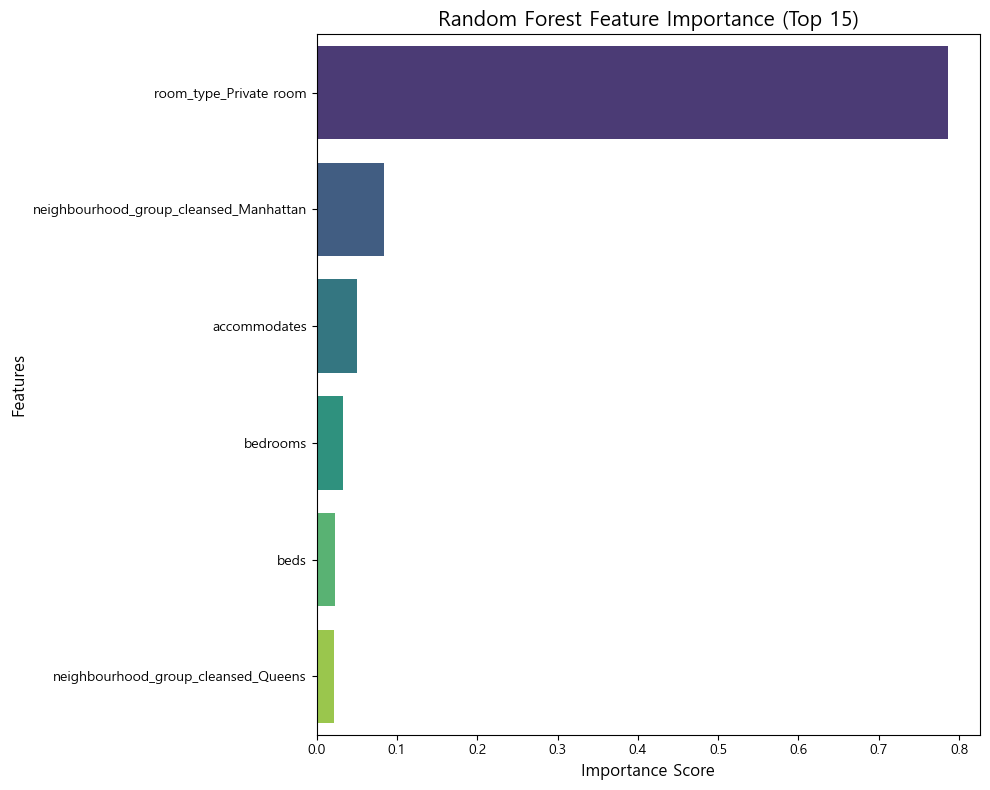

=== 특성 중요도 상위 10개 ===
                               Feature  Importance
                room_type_Private room    0.786645
neighbourhood_group_cleansed_Manhattan    0.084102
                          accommodates    0.050773
                              bedrooms    0.033154
                                  beds    0.023082
   neighbourhood_group_cleansed_Queens    0.022245


In [26]:
# 1. 모델이 계산한 특성 중요도(0~1 사이의 값)를 가져옵니다.
importances = xgb_model.feature_importances_

# 2. X_train의 컬럼명(피처 이름)을 가져옵니다.
feature_names = X_train_dum.columns

# 3. 보기 편하게 '피처 이름'과 '중요도'를 짝지어서 데이터프레임으로 만듭니다.
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 4. 중요도가 높은 순서대로(내림차순) 정렬합니다.
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 5. 시각화 (그래프 그리기)
plt.figure(figsize=(10, 8)) # 그래프 크기 설정
# 상위 15개의 피처만 뽑아서 수평 막대 그래프로 그립니다.
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')

plt.title('Random Forest Feature Importance (Top 15)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# 6. 정확한 수치로도 상위 10개를 출력해 봅니다.
print("=== 특성 중요도 상위 10개 ===")
print(feature_importance_df.head(10).to_string(index=False))